# Synthetic Insurance Data — End-to-End Example

Generate a simple portfolio with 4 features, simulate Poisson claims, fit frequency & severity EBMs, and evaluate calibration.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import claimssimulator as csim
from claimssimulator import gini, poisson_deviance_ratio, gamma_deviance_ratio, calibration_quality_ratio
from sklearn.model_selection import train_test_split
from interpret.glassbox import ExplainableBoostingRegressor

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
SEED = 42

## 1. Define Features

Four features: `age` and `vehicle_age` (continuous, used in risk), `vehicle_type` (categorical, used in risk), and `annual_mileage` (noise — **not** in the risk formula).

In [2]:
feature_spec = [
    csim.Feature('age', csim.LogNormal(mean=3.5, sigma=0.2),
                 csim.Transform(lambda x: x + 18)),
    csim.Feature('vehicle_age', csim.LogNormal(mean=1.8, sigma=0.5),
                 csim.Transform(lambda x: np.clip(x, 0, 25))),
    csim.Feature('vehicle_type', csim.Categorical(
        probabilities=[0.5, 0.3, 0.2],
        labels=['Sedan', 'SUV', 'Truck'],
    )),
    csim.Feature('annual_mileage', csim.LogNormal(mean=10.5, sigma=0.5)),  # noise feature
    csim.Feature('contract_duration_years', csim.Exponential(scale=3),
                 csim.Transform(lambda x: np.clip(x, 1, 10))),
]

## 2. Latent Risk & Data Generation

The frequency risk depends on `age`, `vehicle_age`, and `vehicle_type`. The severity risk depends on `vehicle_age` only. `annual_mileage` is deliberately excluded — a model that picks it up is overfitting.

In [3]:
n_samples = 5_000

feature_spec_with_risk = feature_spec + [
    csim.FormulaFeature(
        name='frequency_risk',
        formula='{b_age} * age + {b_veh} * vehicle_age + vehicle_type[b_vehtype]',
        parameters={
            'b_age': 0.02,
            'b_veh': 0.015,
            'b_vehtype': {'Sedan': 0.0, 'SUV': 0.3, 'Truck': 0.5},
        },
        mean=0.25,
    ),
    csim.FormulaFeature(
        name='severity_risk',
        formula='{b_veh} * vehicle_age',
        parameters={'b_veh': 80.0},
        mean=3000.0,
    ),
]

feature_gen = csim.FeatureDefinition(feature_spec_with_risk)
risk_df = feature_gen.generate(n_samples=n_samples, random_seed=SEED)

claim_sim = csim.ClaimsSimulator(
    generator='Poisson',
    param_columns={'rate': 'frequency_risk'},
    time_to_simulate='contract_duration_years',
    max_exposure=1.0,
    claim_counter='past_claims',
    renewal_mode='contract_end',
    severity_column='severity_risk',
    severity_cv=0.3,
    random_seed=SEED,
)
df = claim_sim.simulate(risk_df)

print(f"Rows: {len(df):,}  |  Claims: {df['claim'].sum():,.0f}  |  "
      f"Obs rate: {df['claim'].sum()/df['exposure'].sum():.4f}")
df.head()

Rows: 20,748  |  Claims: 3,743  |  Obs rate: 0.2459


,age,vehicle_age,vehicle_type,annual_mileage,contract_duration_years,frequency_risk,severity_risk,exposure,claim,start_time,end_time,past_claims,claim_cost,contract_id
0,53.196386,5.317610,SUV,27462.567440,1.000000,0.272043,2325.104266,1.000000,0,0.0,1.000000,0,0.000000,0
1,44.896689,5.208318,Sedan,53233.878025,5.228118,0.183924,2277.316976,1.000000,0,0.0,1.000000,0,0.000000,1
2,44.896689,5.208318,Sedan,53233.878025,5.228118,0.183924,2277.316976,1.000000,0,1.0,2.000000,0,0.000000,1
3,44.896689,5.208318,Sedan,53233.878025,5.228118,0.183924,2277.316976,1.000000,0,2.0,3.000000,0,0.000000,1
4,44.896689,5.208318,Sedan,53233.878025,5.228118,0.183924,2277.316976,0.922253,1,3.0,3.922253,0,2420.441243,1


## 3. Train / Test Split & Model Features

All four observable features are given to the model — including the noise feature `annual_mileage`.

In [4]:
feature_cols = ['age', 'vehicle_age', 'vehicle_type', 'annual_mileage']
df['vehicle_type'] = df['vehicle_type'].astype('category')

idx_train, idx_test = train_test_split(df.index.unique(), test_size=0.25, random_state=SEED)
train = df.loc[idx_train].copy()
test  = df.loc[idx_test].copy()

print(f"Train: {len(train):,} rows ({train['claim'].sum():,.0f} claims)")
print(f"Test : {len(test):,} rows  ({test['claim'].sum():,.0f} claims)")

Train: 15,561 rows (2,790 claims)
Test : 5,187 rows  (953 claims)


## 4. Frequency Model (Poisson EBM)

In [5]:
X_train_freq = train[feature_cols]
y_train_freq = train['claim'] / train['exposure']
X_test_freq  = test[feature_cols]
y_test_freq  = test['claim'] / test['exposure']

ebm_freq = ExplainableBoostingRegressor(
    max_bins=64, max_rounds=300, learning_rate=0.05,
    objective='poisson_deviance', random_state=SEED,
)
ebm_freq.fit(X_train_freq, y_train_freq, sample_weight=train['exposure'])
print("Frequency EBM trained ✓")

Frequency EBM trained ✓


## 5. Severity Model (Gamma EBM)

In [6]:
train_sev = train[train['claim'] == 1].copy()
test_sev  = test[test['claim'] == 1].copy()

X_train_sev = train_sev[feature_cols]
y_train_sev = train_sev['claim_cost']
X_test_sev  = test_sev[feature_cols]
y_test_sev  = test_sev['claim_cost']

ebm_sev = ExplainableBoostingRegressor(
    max_bins=64, max_rounds=300, learning_rate=0.05,
    objective='gamma_deviance', random_state=SEED,
)
ebm_sev.fit(X_train_sev, y_train_sev)
print(f"Severity EBM trained ✓  ({len(train_sev):,} claims)")

Severity EBM trained ✓  (2,790 claims)


## 6. Shape Functions

Check that the model recovered the true signal: `age` ↑, `vehicle_age` ↑, `vehicle_type` effect, and `annual_mileage` ≈ flat (noise).

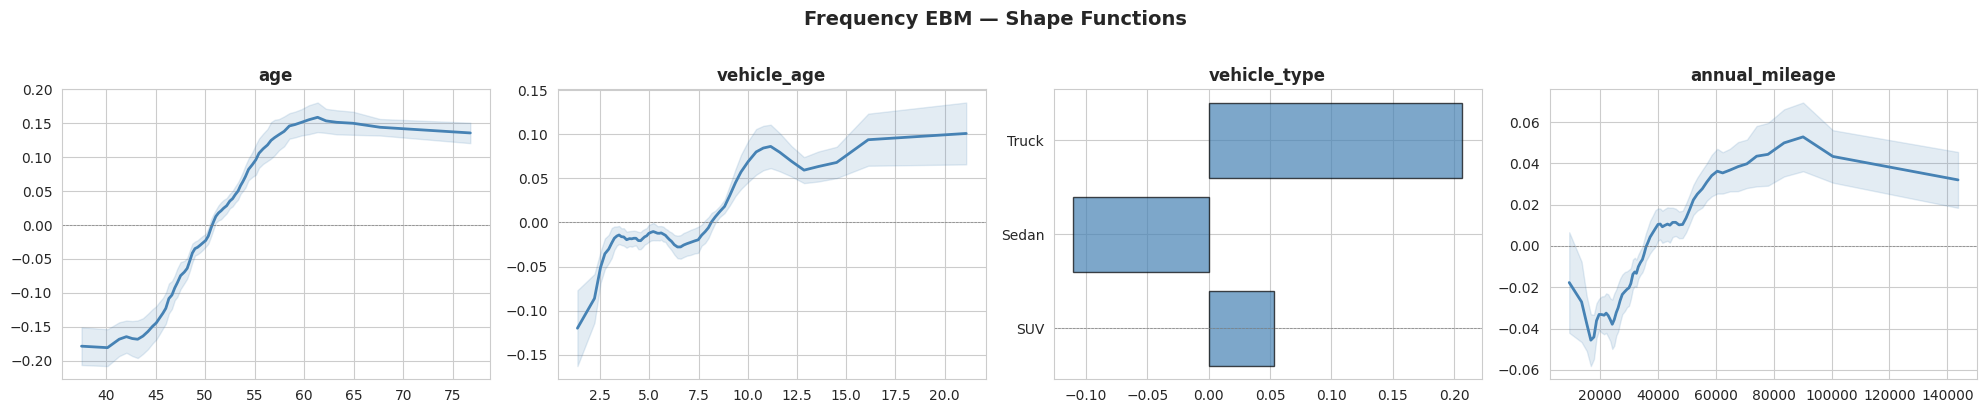

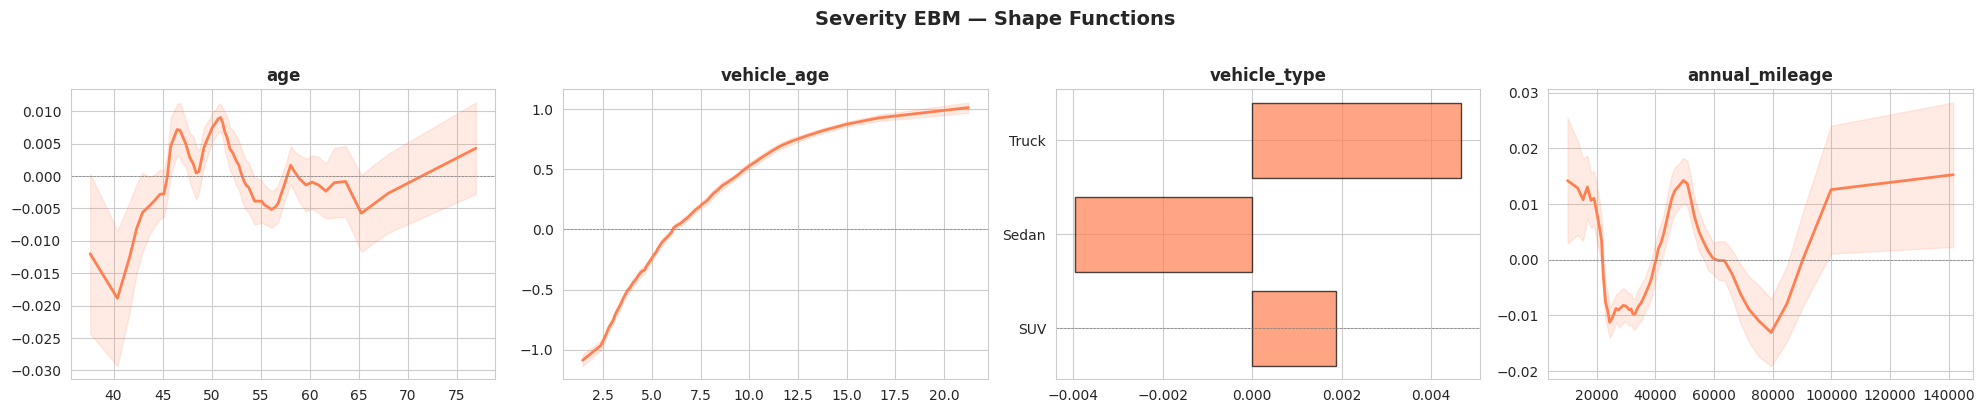

In [7]:
def plot_ebm_shapes(ebm, feature_cols, title, color='steelblue'):
    global_exp = ebm.explain_global()
    n = len(feature_cols)
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 4))
    for i, name in enumerate(global_exp.data()['names'][:n]):
        data_dict = global_exp.data(i)
        xs, ys = data_dict['names'], np.array(data_dict['scores'])
        ax = axes[i]
        if isinstance(xs[0], str):
            ax.barh(xs, ys, edgecolor='black', alpha=0.7, color=color)
        else:
            xs = np.array(xs)
            mids = (xs[:-1] + xs[1:]) / 2
            ax.plot(mids, ys, lw=2, color=color)
            if 'upper_bounds' in data_dict:
                ax.fill_between(mids, data_dict['lower_bounds'], data_dict['upper_bounds'], alpha=0.15, color=color)
        ax.set_title(name, fontweight='bold')
        ax.axhline(0, color='grey', lw=0.5, ls='--')
    fig.suptitle(title, fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    return fig

fig = plot_ebm_shapes(ebm_freq, feature_cols, 'Frequency EBM — Shape Functions')
plt.show()

fig = plot_ebm_shapes(ebm_sev, feature_cols, 'Severity EBM — Shape Functions', color='coral')
plt.show()

## 7. Calibration

A model is **well-calibrated** when predicted rates match observed rates across risk levels. We bucket predictions into deciles and compare predicted vs observed vs true risk.

/tmp/ipykernel_380397/3984933679.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  cal_freq = test.groupby('freq_decile').apply(


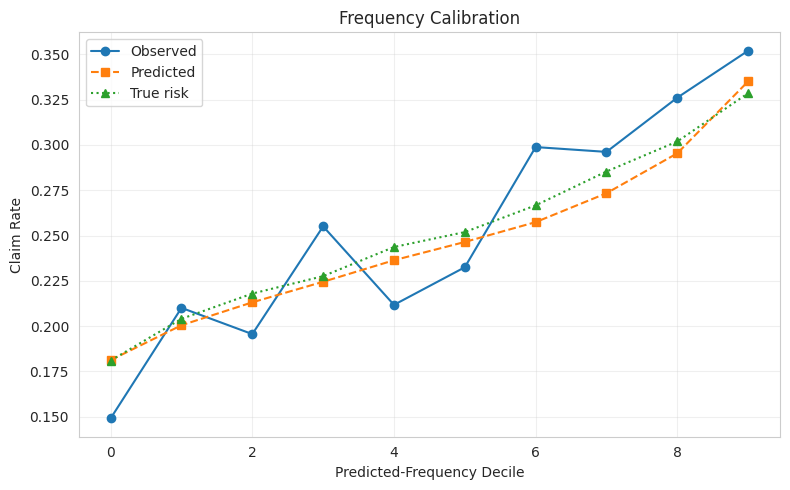

In [8]:
# ── Frequency calibration ──
test['pred_freq'] = ebm_freq.predict(X_test_freq)
test['freq_decile'] = pd.qcut(test['pred_freq'], q=10, labels=False, duplicates='drop')

cal_freq = test.groupby('freq_decile').apply(
    lambda g: pd.Series({
        'predicted':  np.average(g['pred_freq'], weights=g['exposure']),
        'observed':   g['claim'].sum() / g['exposure'].sum(),
        'true_risk':  np.average(g['frequency_risk'], weights=g['exposure']),
    })
).reset_index()

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(cal_freq['freq_decile'], cal_freq['observed'],  'o-', label='Observed')
ax.plot(cal_freq['freq_decile'], cal_freq['predicted'], 's--', label='Predicted')
ax.plot(cal_freq['freq_decile'], cal_freq['true_risk'], '^:', label='True risk')
ax.set(xlabel='Predicted-Frequency Decile', ylabel='Claim Rate',
       title='Frequency Calibration')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

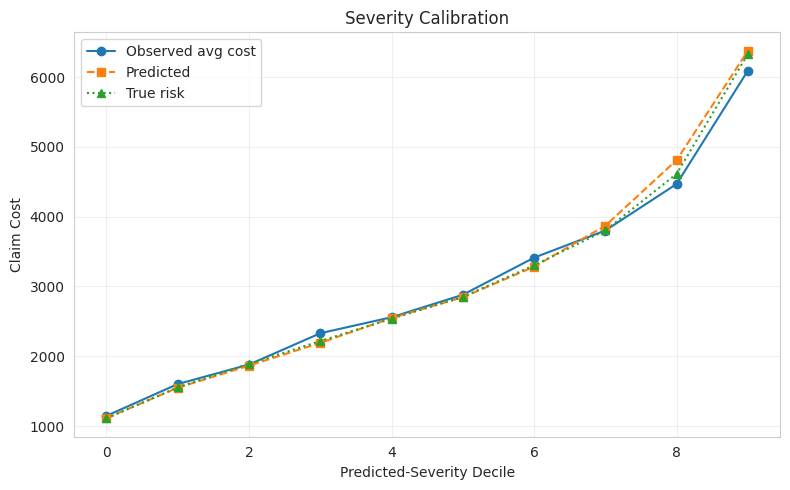

In [9]:
# ── Severity calibration ──
test_sev['pred_sev'] = ebm_sev.predict(X_test_sev)
test_sev['sev_decile'] = pd.qcut(test_sev['pred_sev'], q=10, labels=False, duplicates='drop')

cal_sev = test_sev.groupby('sev_decile').agg(
    predicted  = ('pred_sev',      'mean'),
    observed   = ('claim_cost',    'mean'),
    true_risk  = ('severity_risk', 'mean'),
).reset_index()

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(cal_sev['sev_decile'], cal_sev['observed'],  'o-', label='Observed avg cost')
ax.plot(cal_sev['sev_decile'], cal_sev['predicted'], 's--', label='Predicted')
ax.plot(cal_sev['sev_decile'], cal_sev['true_risk'], '^:', label='True risk')
ax.set(xlabel='Predicted-Severity Decile', ylabel='Claim Cost',
       title='Severity Calibration')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

/tmp/ipykernel_380397/2521467334.py:7: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  cal_pp = test.groupby('pp_decile').apply(


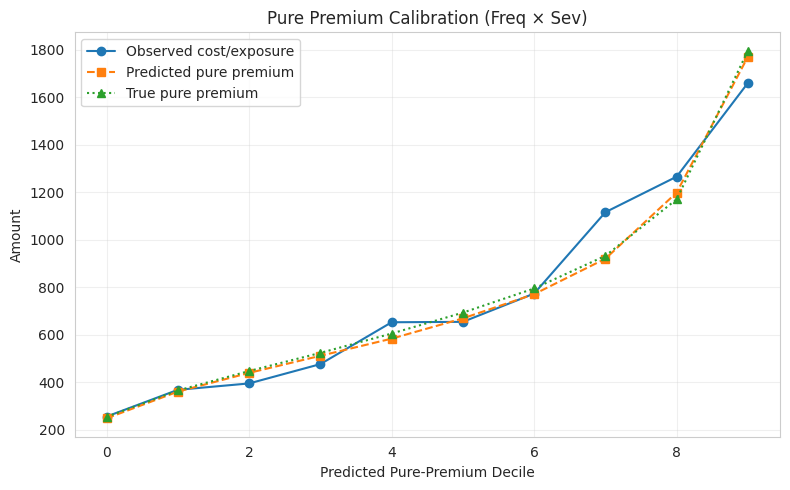

In [10]:
# ── Pure-premium calibration (freq × sev) ──
test['pred_sev_all'] = ebm_sev.predict(test[feature_cols])
test['pred_pp']  = test['pred_freq'] * test['pred_sev_all']
test['true_pp']  = test['frequency_risk'] * test['severity_risk']
test['pp_decile'] = pd.qcut(test['pred_pp'], q=10, labels=False, duplicates='drop')

cal_pp = test.groupby('pp_decile').apply(
    lambda g: pd.Series({
        'predicted':    np.average(g['pred_pp'], weights=g['exposure']),
        'true_premium': np.average(g['true_pp'], weights=g['exposure']),
        'observed_cost': g['claim_cost'].sum() / g['exposure'].sum(),
    })
).reset_index()

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(cal_pp['pp_decile'], cal_pp['observed_cost'], 'o-', label='Observed cost/exposure')
ax.plot(cal_pp['pp_decile'], cal_pp['predicted'],     's--', label='Predicted pure premium')
ax.plot(cal_pp['pp_decile'], cal_pp['true_premium'],  '^:', label='True pure premium')
ax.set(xlabel='Predicted Pure-Premium Decile', ylabel='Amount',
       title='Pure Premium Calibration (Freq × Sev)')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 8. Metrics

| Metric | What it measures |
|--------|-----------------|
| **Gini** | Ranking power (higher = better discrimination) |
| **Poisson EDR** | Explained deviance ratio for frequency (like R² for counts) |
| **Gamma EDR** | Explained deviance ratio for severity (like R² for costs) |

In [ ]:
# ── Frequency metrics ──
pred_freq = test['pred_freq'].values
obs_freq  = (test['claim'] / test['exposure']).values
w_freq    = test['exposure'].values

freq_gini = gini(test['claim'].values, pred_freq, w_freq)
freq_edr  = poisson_deviance_ratio(obs_freq, pred_freq, w_freq)

print("=== Frequency Model (test set) ===")
print(f"  Gini          : {freq_gini:.4f}")
print(f"  Poisson EDR   : {freq_edr:.4f}")


# ── Severity metrics ──
pred_sev = test_sev['pred_sev'].values
obs_sev  = test_sev['claim_cost'].values
w_sev    = np.ones(len(test_sev))  # equal weights for severity

sev_gini = gini(obs_sev, pred_sev, w_sev)
sev_edr  = gamma_deviance_ratio(obs_sev, pred_sev, w_sev)

print("\n=== Severity Model (test set) ===")
print(f"  Gini          : {sev_gini:.4f}")
print(f"  Gamma EDR     : {sev_edr:.4f}")


=== Frequency Model (test set) ===
  Gini          : 0.1307
  Poisson EDR   : 0.0095
  CQR           : 0.1937

=== Severity Model (test set) ===
  Gini          : 0.2631
  Gamma EDR     : 0.7207
  CQR           : 0.9774
